### 等宽 bins=5

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../datasets/beijing_housing.csv', encoding='GBK')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23133 entries, 0 to 23132
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  23133 non-null  int64  
 1   小区名称        23133 non-null  object 
 2   区域位置        23133 non-null  object 
 3   子区域         23133 non-null  object 
 4   经度          23133 non-null  float64
 5   纬度          23133 non-null  float64
 6   总价          23133 non-null  float64
 7   单价          23133 non-null  float64
 8   关注度         23133 non-null  int64  
 9   房屋户型        23133 non-null  object 
 10  所在楼层        23133 non-null  object 
 11  建筑面积        23133 non-null  float64
 12  户型结构        22487 non-null  object 
 13  套内面积        9223 non-null   float64
 14  建筑类型        22766 non-null  object 
 15  房屋朝向        23133 non-null  object 
 16  建筑结构        23133 non-null  object 
 17  装修情况        23133 non-null  object 
 18  梯户比例        23085 non-null  object 
 19  供暖方式        23010 non-nul

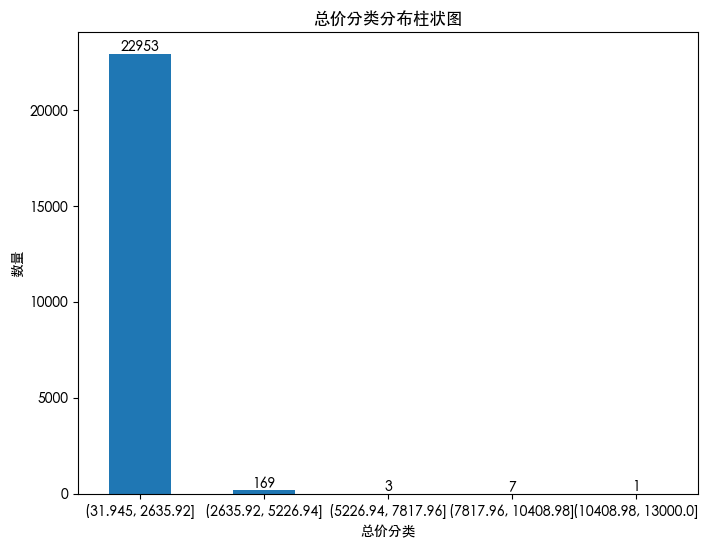

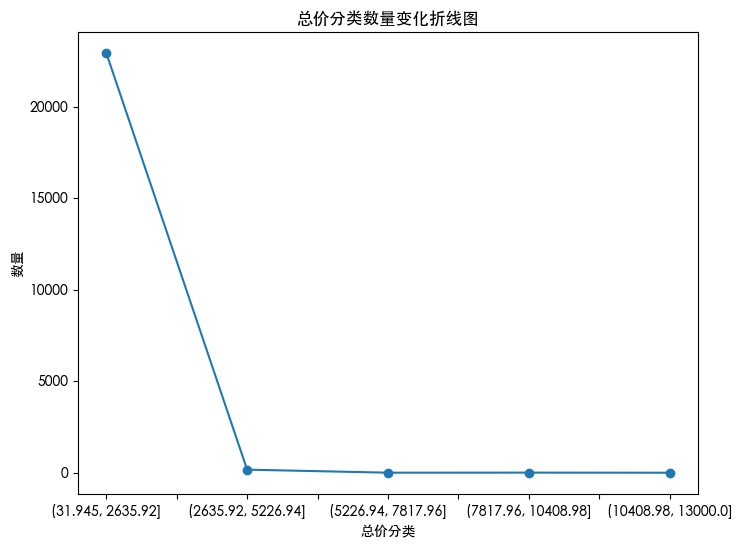

In [30]:
# 对总价进行等宽分，分成 5 份
df['总价分类'] = pd.cut(df['总价'], bins=5)

# 统计每个分类的数量
bin_counts = df['总价分类'].value_counts().sort_index()

# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['Heiti TC']      
plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示问题

# 绘制柱状图
plt.figure(figsize=(8, 6))
bars = bin_counts.plot(kind='bar')
plt.title('总价分类分布柱状图')
plt.xlabel('总价分类')
plt.ylabel('数量')
plt.xticks(rotation=0)   #旋转x轴标签的角度

# 添加数据标签
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')

plt.show()

# 绘制折线图
plt.figure(figsize=(8, 6))
bin_counts.plot(kind='line', marker='o')
plt.title('总价分类数量变化折线图')
plt.xlabel('总价分类')
plt.ylabel('数量')
plt.xticks(rotation=0)
plt.show()

### 等频 q=5

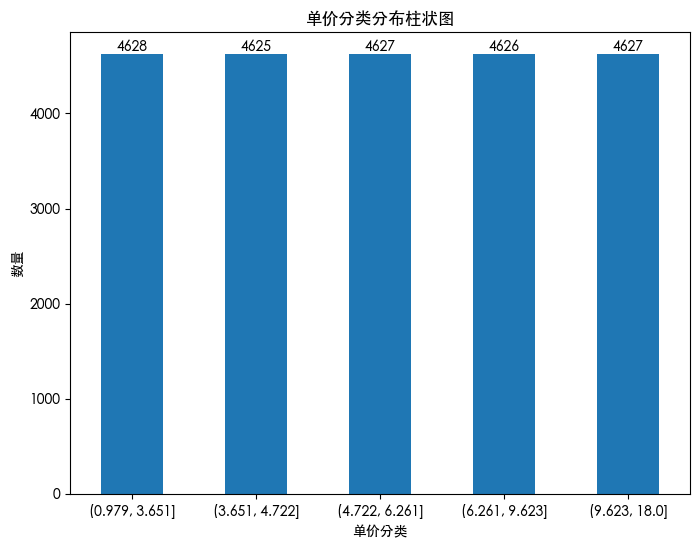

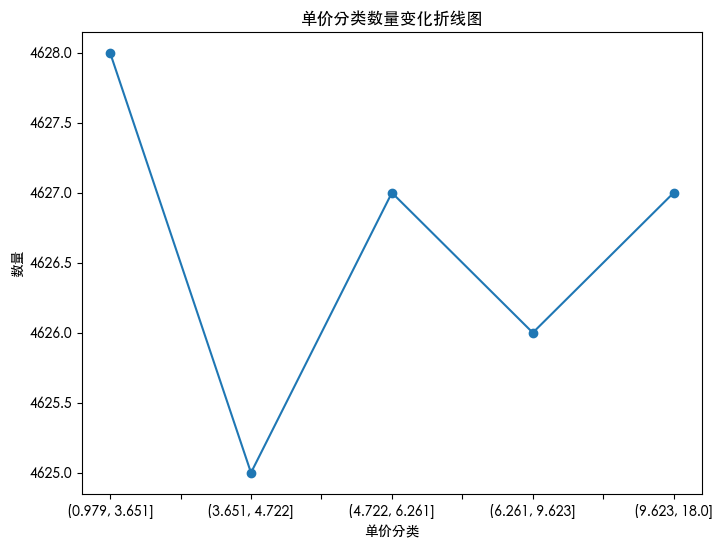

In [28]:
# 对单价进行等频分类，分成 5 份
df['单价分类'] = pd.qcut(df['单价'], q=5)

# 统计每个分类的数量
bin_counts = df['单价分类'].value_counts().sort_index()

# 绘制柱状图
plt.figure(figsize=(8, 6))
bars = bin_counts.plot(kind='bar')
plt.title('单价分类分布柱状图')
plt.xlabel('单价分类')
plt.ylabel('数量')
plt.xticks(rotation=0)

# 添加数据标签
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')

plt.show()

# 绘制折线图
plt.figure(figsize=(8, 6))
bin_counts.plot(kind='line', marker='o')
plt.title('单价分类数量变化折线图')
plt.xlabel('单价分类')
plt.ylabel('数量')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['Heiti TC']      
plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示问题     

data = pd.read_csv('../datasets/creditcard.csv')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 标准化 Amount 和 Time
scaler = StandardScaler()
data[['Amount', 'Time']] = scaler.fit_transform(data[['Amount', 'Time']])
print(data.head())

#分离特征 和 标签
X = data.drop('Class', axis=1)
y = data['Class']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 输出划分后的数据集大小
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

from sklearn.model_selection import train_test_split

max_depth_values = [1, 2, 3, 4, 5,6,7,8,9, 10, 15, None]
accuracy_scores = []

# 训练模型并计算准确率
for max_depth in max_depth_values:
    clf2 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=max_depth)
    clf2.fit(X_train, y_train)
    y_pred2 = clf2.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred2)
    accuracy_scores.append(accuracy)
    print(f"Max Depth: {max_depth}, Accuracy: {accuracy:.4f}")


